In [2]:
import sys
import os
sys.path.append(os.path.join(os.getcwd(), "..", "..", "..", "..", ".."))
sys.path.append(os.path.join(os.getcwd(), "..", "..", "..", ".."))
sys.path.append(os.path.join(os.getcwd(), "..", "..", ".."))
sys.path.append(os.path.join(os.getcwd(), "..", ".."))
sys.path

['/home/blessyantony/miniconda3/envs/haven/lib/python311.zip',
 '/home/blessyantony/miniconda3/envs/haven/lib/python3.11',
 '/home/blessyantony/miniconda3/envs/haven/lib/python3.11/lib-dynload',
 '',
 '/home/blessyantony/miniconda3/envs/haven/lib/python3.11/site-packages',
 '/home/blessyantony/dev/git/HAVEN/src/jupyter_notebooks/results-analysis/coronaviridae/../../../../..',
 '/home/blessyantony/dev/git/HAVEN/src/jupyter_notebooks/results-analysis/coronaviridae/../../../..',
 '/home/blessyantony/dev/git/HAVEN/src/jupyter_notebooks/results-analysis/coronaviridae/../../..',
 '/home/blessyantony/dev/git/HAVEN/src/jupyter_notebooks/results-analysis/coronaviridae/../..']

In [3]:
import pandas as pd
import os
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

from src.utils import utils, evaluation_utils, visualization_utils
from sklearn.metrics import auc, precision_recall_curve
from statistics import mean
from datetime import datetime

In [4]:
# file_paths = {
#     "msl128vs30_s64_UA": os.path.join(os.getcwd(), "..","..", "..", "..", "output/raw/coronaviridae_s_prot_variants/20240824/sars-cov-2/uniprot/cov-S-multi-transfer_learning_mlm_hybrid_attn_fnn_2l_lr1e-4/msl128vs30_s64/tl_tf_multi_sarscov2_variants_s.csv"),
#     "msl128vs30cls_s64_UA": os.path.join(os.getcwd(), "..","..", "..", "..", "output/raw/coronaviridae_s_prot_variants/20240825/sars-cov-2/uniprot/cov-S-multi-transfer_learning_mlm_hybrid_attn_fnn_2l_lr1e-4/msl128vs30cls_s64/tl_tf_multi_sarscov2_variants_s.csv"),
#     "msl256vs30_s64_UA": os.path.join(os.getcwd(), "..","..", "..", "..", "output/raw/coronaviridae_s_prot_variants/20240808/sars-cov-2/uniprot/cov-S-multi-transfer_learning_mlm_hybrid_attn_fnn_2l_lr1e-4/msl256vs30_s64/tl_tf_multi_sarscov2_variants_s.csv"),
#     "msl256vs30cls_s64_UA": os.path.join(os.getcwd(), "..","..", "..", "..", "output/raw/coronaviridae_s_prot_variants/20240808/sars-cov-2/uniprot/cov-S-multi-transfer_learning_mlm_hybrid_attn_fnn_2l_lr1e-4/msl256vs30cls_s64/tl_tf_multi_sarscov2_variants_s.csv")
# }
id_col = "accession_id"
file_paths = {
    #"msl128vs30_ae_bn_s64_UA": os.path.join(os.getcwd(), "..","..", "..", "..", "output/raw/coronaviridae_s_prot_variants/20240829/sars-cov-2/uniprot/cov-S-multi-transfer_learning_mlm_hybrid_attn_fnn_2l_lr1e-4/msl128ae_bn_vs30_s64/tl_tf_multi_sarscov2_variants_s.csv"),
    #"msl128vs30cls_ae_bn_s64_UA": os.path.join(os.getcwd(), "..","..", "..", "..", "output/raw/coronaviridae_s_prot_variants/20240829/sars-cov-2/uniprot/cov-S-multi-transfer_learning_mlm_hybrid_attn_fnn_2l_lr1e-4/msl128ae_bn_vs30cls_s64/tl_tf_multi_sarscov2_variants_s.csv"),
    #"ProtienBert": os.path.join(os.getcwd(), "..","..", "..", "..", "output/raw/coronaviridae_s_prot_uniprot_embl_vertebrates_t0.01_c8/20240902/host_multi/proteinbert/uniprot_cov_s_prot_embl_hosts/sarscov2_variants_s_prediction_results_20240902_224534.csv"),
    "ProtT5": os.path.join(os.getcwd(), "..","..", "..", "..", "output/raw/sarscov2_s_prot_variants/20250201/uniref90/external/prot_t5_xl_uniref50_lr3e-4.csv"),
    "ProstT5": os.path.join(os.getcwd(), "..","..", "..", "..", "output/raw/sarscov2_s_prot_variants/20250201/uniref90/external/prostt5_lr3e-4.csv"),
    #"ESM2-35M": os.path.join(os.getcwd(), "..","..", "..", "..", "output/raw/sarscov2_s_prot_variants/20250123/uniref90/external/esm2_t12_35M_UR50D_lr1e-4.csv"),
    #"ESM2-650M": os.path.join(os.getcwd(), "..","..", "..", "..", "output/raw/sarscov2_s_prot_variants/20250123/uniref90/external/esm2_t33_650M_UR50D_lr1e-4.csv"),
    #"ESM2-3B": os.path.join(os.getcwd(), "..","..", "..", "..", "output/raw/sarscov2_s_prot_variants/20250123/uniref90/external/esm2_t36_3B_UR50D_lr1e-4.csv"),
    #"ESM3": os.path.join(os.getcwd(), "..","..", "..", "..", "output/raw/sarscov2_s_prot_variants/20250123/uniref90/external/esm3_lr1e-4.csv"),
    #"ProtienBert-2048": os.path.join(os.getcwd(), "..","..", "..", "..", "output/raw/coronaviridae_s_prot_uniprot_embl_vertebrates_t0.01_c8/20240902/host_multi/proteinbert/uniprot_cov_s_prot_embl_hosts/sarscov2_variants_s_prediction_results_20240903_132845.csv"),
    #"VirProBert-msl1366": os.path.join(os.getcwd(), "..","..", "..", "..", "output/raw/coronaviridae_s_prot_variants/20240903/sars-cov-2/uniprot/cov-S-multi-transfer_learning_mlm_msl1366/tl_tf_multi_sarscov2_variants_s.csv"),
    #"Hybd-sl256s64_UA": os.path.join(os.getcwd(), "..","..", "..", "..", "output/raw/coronaviridae_s_prot_perturbation/20240829/sars-cov-2/uniprot/cov-S-multi-transfer_learning_mlm_hybrid_attn_fnn_2l_lr1e-4/msl256ae_bn_vs30_s64/tl_tf_multi_sarscov2_variants_s.csv"),
    #"Hybd-sl256s64_CLS_UA": os.path.join(os.getcwd(), "..","..", "..", "..", "output/raw/coronaviridae_s_prot_variants/20240829/sars-cov-2/uniprot/cov-S-multi-transfer_learning_mlm_hybrid_attn_fnn_2l_lr1e-4/msl256ae_bn_vs30cls_s64/tl_tf_multi_sarscov2_variants_s.csv"),
    "HAVEN": os.path.join(os.getcwd(), "..","..", "..", "..", "output/raw/sarscov2_s_prot_variants/20250123/uniref90/cov-S-multi-transfer_learning_mlm_hybrid_attn_fnn_2l_lr1e-4/msl256ae_bn_vs30cls_s64.csv")
}

In [5]:
dfs = []
for k, v in file_paths.items():
    df = pd.read_csv(v)
    df["model"] = k
    index_seq_pred = df[df[id_col] == "YP_009724390.1"]["Human"].values[0]
    df["Human_pred_diff"] = df["Human"] - index_seq_pred
    dfs.append(df)
df = pd.concat(dfs)
df

,accession_id,Cat,Chicken,Chinese rufous horseshoe bat,Ferret,Gray wolf,Horshoe bat,Human,Pig,y_true,pangolin_lineage,geo_location,seq_length,model,Human_pred_diff
0,UDW43218.1,0.006330,1.050447e-02,0.006680,0.032874,0.005100,0.019163,0.909526,0.009823,Human,C.37,USA: Texas,1266,ProtT5,0.877108
1,UJZ71565.1,0.008074,2.483119e-07,0.000002,0.911808,0.033276,0.006743,0.028032,0.012065,Human,B.1.1.529,USA,1273,ProtT5,-0.004386
2,UES70215.1,0.003342,1.227013e-03,0.795080,0.015439,0.004009,0.139110,0.039315,0.002477,Human,B.1.526,USA,1273,ProtT5,0.006897
3,QSE06394.1,0.003247,1.127909e-03,0.806335,0.014812,0.003732,0.130946,0.037447,0.002354,Human,P.2,USA: California,1273,ProtT5,0.005029
4,QTN76737.1,0.003458,1.174976e-03,0.801658,0.015148,0.003921,0.133582,0.038618,0.002440,Human,P.2,USA: New Jersey,1273,ProtT5,0.006200
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1521,QVL01758.1,0.040101,4.819087e-06,0.614859,0.024371,0.003751,0.032906,0.273032,0.010976,Human,B.1.1.7,USA: Michigan,1270,HAVEN,-0.468530
1522,QVG32451.1,0.024636,5.279566e-06,0.142835,0.015277,0.003411,0.029747,0.768989,0.015099,Human,B.1.617.1,USA: Illinois,1273,HAVEN,0.027428
1523,UIT75201.1,0.008459,1.363562e-06,0.070926,0.010776,0.001566,0.009238,0.889716,0.009317,Human,B.1.427,USA,1273,HAVEN,0.148155
1524,UGW14958.1,0.021574,8.265451e-06,0.166947,0.015973,0.003626,0.032665,0.739008,0.020199,Human,B.1.427,USA,1273,HAVEN,-0.002553


##### Process ESM3 separately because it was executed using the pertubation analysis pipeline and not the sarscov2 variant pipeline.

In [6]:
esm3_df = pd.read_csv(os.path.join(os.getcwd(), "..","..", "..", "..", "output/raw/sarscov2_s_prot_variants/20250123/uniref90/external/esm3_lr1e-4.csv"))
esm3_df["model"] = "ESM3"
esm3_df

,Cat,Chicken,Chinese rufous horseshoe bat,Ferret,Gray wolf,Horshoe bat,Human,Pig,accession_id,y_true,model
0,0.013420,0.000370,0.246287,0.021458,0.009859,0.079028,0.613571,0.016007,QUR40592.1,Human,ESM3
1,0.002790,0.000780,0.748513,0.008765,0.003287,0.196386,0.029051,0.010427,UCK71595.1,Human,ESM3
2,0.002410,0.000846,0.748511,0.007380,0.003473,0.199265,0.028266,0.009849,UEA15086.1,Human,ESM3
3,0.015028,0.000223,0.074244,0.022930,0.016191,0.053944,0.808746,0.008695,QVN41227.1,Human,ESM3
4,0.002948,0.000823,0.706261,0.009218,0.003386,0.236314,0.029563,0.011487,QYZ52400.1,Human,ESM3
...,...,...,...,...,...,...,...,...,...,...,...
1521,0.033002,0.003407,0.076918,0.020166,0.010857,0.016620,0.824890,0.014139,QUI11057.1,Human,ESM3
1522,0.002282,0.000688,0.766168,0.007731,0.002871,0.182816,0.027462,0.009982,QVE76837.1,Human,ESM3
1523,0.002649,0.000806,0.774727,0.008059,0.003375,0.171108,0.028715,0.010560,QTS06228.1,Human,ESM3
1524,0.008682,0.000308,0.506420,0.020655,0.019005,0.082999,0.341344,0.020586,UIT31286.1,Human,ESM3


In [7]:
# get the mapping between accession ids and the pangolin lineage
accession_id_pangolin_lineage_map = df[df["model"] == "HAVEN"][["accession_id", "pangolin_lineage"]].set_index("accession_id").to_dict()["pangolin_lineage"]
#accession_id_pangolin_lineage_map

In [8]:
esm3_df["pangolin_lineage"] = esm3_df.apply(lambda x: accession_id_pangolin_lineage_map[x["accession_id"]], axis=1)
esm3_df.shape

(1526, 12)

In [9]:
df = pd.concat([df, esm3_df])

In [10]:
df["model"].value_counts()

ProtT5     1526
ProstT5    1526
HAVEN      1526
ESM3       1526
Name: model, dtype: int64

In [11]:
order = list(df["pangolin_lineage"].sort_values().unique())
order.remove("B")
order = ["B"] + order
order

['B',
 'B.1.1.529',
 'B.1.1.7',
 'B.1.351',
 'B.1.427',
 'B.1.429',
 'B.1.525',
 'B.1.526',
 'B.1.617.1',
 'B.1.617.2',
 'B.1.621',
 'BA.1',
 'C.37',
 'P.1',
 'P.2',
 'P.3']

In [12]:
models = list(df["model"].unique())
models = ['ProtT5', 'ProstT5', 'ESM3', 'HAVEN']
models

['ProtT5', 'ProstT5', 'ESM3', 'HAVEN']

In [13]:
who_designation_df = pd.read_csv(os.path.join(os.getcwd(), "..","..", "..", "..", "input/data/coronaviridae/20240313/sarscov2/sarscov2_who_designated_voc.csv"))
who_designation_df

,pango_lineage,who_variant,designation,first_designation_date,location
0,B,Wuhan-Hu-1,Index,12/01/2019,China
1,B.1.1.7,Alpha,VOC,12/08/2020,United Kingdom
2,B.1.351,Beta,VOC,12/18/2020,South Africa
3,P.1,Gamma,VOC,1/11/2021,Brazil
4,B.1.617.2,Delta,VOC,5/11/2021,India
5,B.1.427,Epsilon,VOI,3/5/2021,USA
6,B.1.429,Epsilon,VOI,3/5/2021,USA
7,P.2,Zeta,VOI,3/17/2021,Brazil
8,B.1.525,Eta,VOI,3/17/2021,Nigeria
9,P.3,Theta,VOI,3/24/2021,Philippines


In [14]:
who_designation_df["pango_who_annotation"] = who_designation_df["pango_lineage"] + " (" + who_designation_df["who_variant"] + ")" 
variant_order = who_designation_df["pango_who_annotation"].unique()
variant_order

array(['B (Wuhan-Hu-1)', 'B.1.1.7 (Alpha)', 'B.1.351 (Beta)',
       'P.1 (Gamma)', 'B.1.617.2 (Delta)', 'B.1.427 (Epsilon)',
       'B.1.429 (Epsilon)', 'P.2 (Zeta)', 'B.1.525 (Eta)', 'P.3 (Theta)',
       'B.1.526 (Iota)', 'B.1.617.1 (Kappa)', 'C.37 (Lambda)',
       'B.1.621 (Mu)', 'B.1.1.529 (Omicron)', 'BA.1 (Omicron)'],
      dtype=object)

In [15]:
who_designation_df.rename(columns={"pango_lineage": "pangolin_lineage"}, inplace=True)

In [16]:
df = pd.merge(df, who_designation_df, how="inner", on="pangolin_lineage")

In [17]:
df = df.rename(columns={"Horshoe bat": "Horseshoe bat"})

In [18]:
def get_annotation(x):
    mean_val = np.mean(x)
    std_val = np.std(x)
    return "{:.2f}".format(mean_val) + "\n" + u"\u00B1" + "{:.2f}".format(std_val)
    
def get_annotation_df(heatmap_df, model_df):
    annot_df = pd.DataFrame(0, index=heatmap_df.index, columns=heatmap_df.columns)
    annot_idx = heatmap_df.idxmax(axis=1).reset_index()
    mean_std_df = model_df.groupby("pango_who_annotation").agg(lambda x: get_annotation(x))
    for item in annot_idx.values:
        annot_df.loc[item[0], item[1]] = mean_std_df.loc[item[0], item[1]]
        annot_df.loc[item[0], "Human"] = mean_std_df.loc[item[0], "Human"]
    annot_df = annot_df.astype(str)
    annot_df[annot_df == "0"] = ""
    return annot_df

model = (1526, 8)
model = (1526, 8)
model = (1526, 8)
model = (1526, 8)


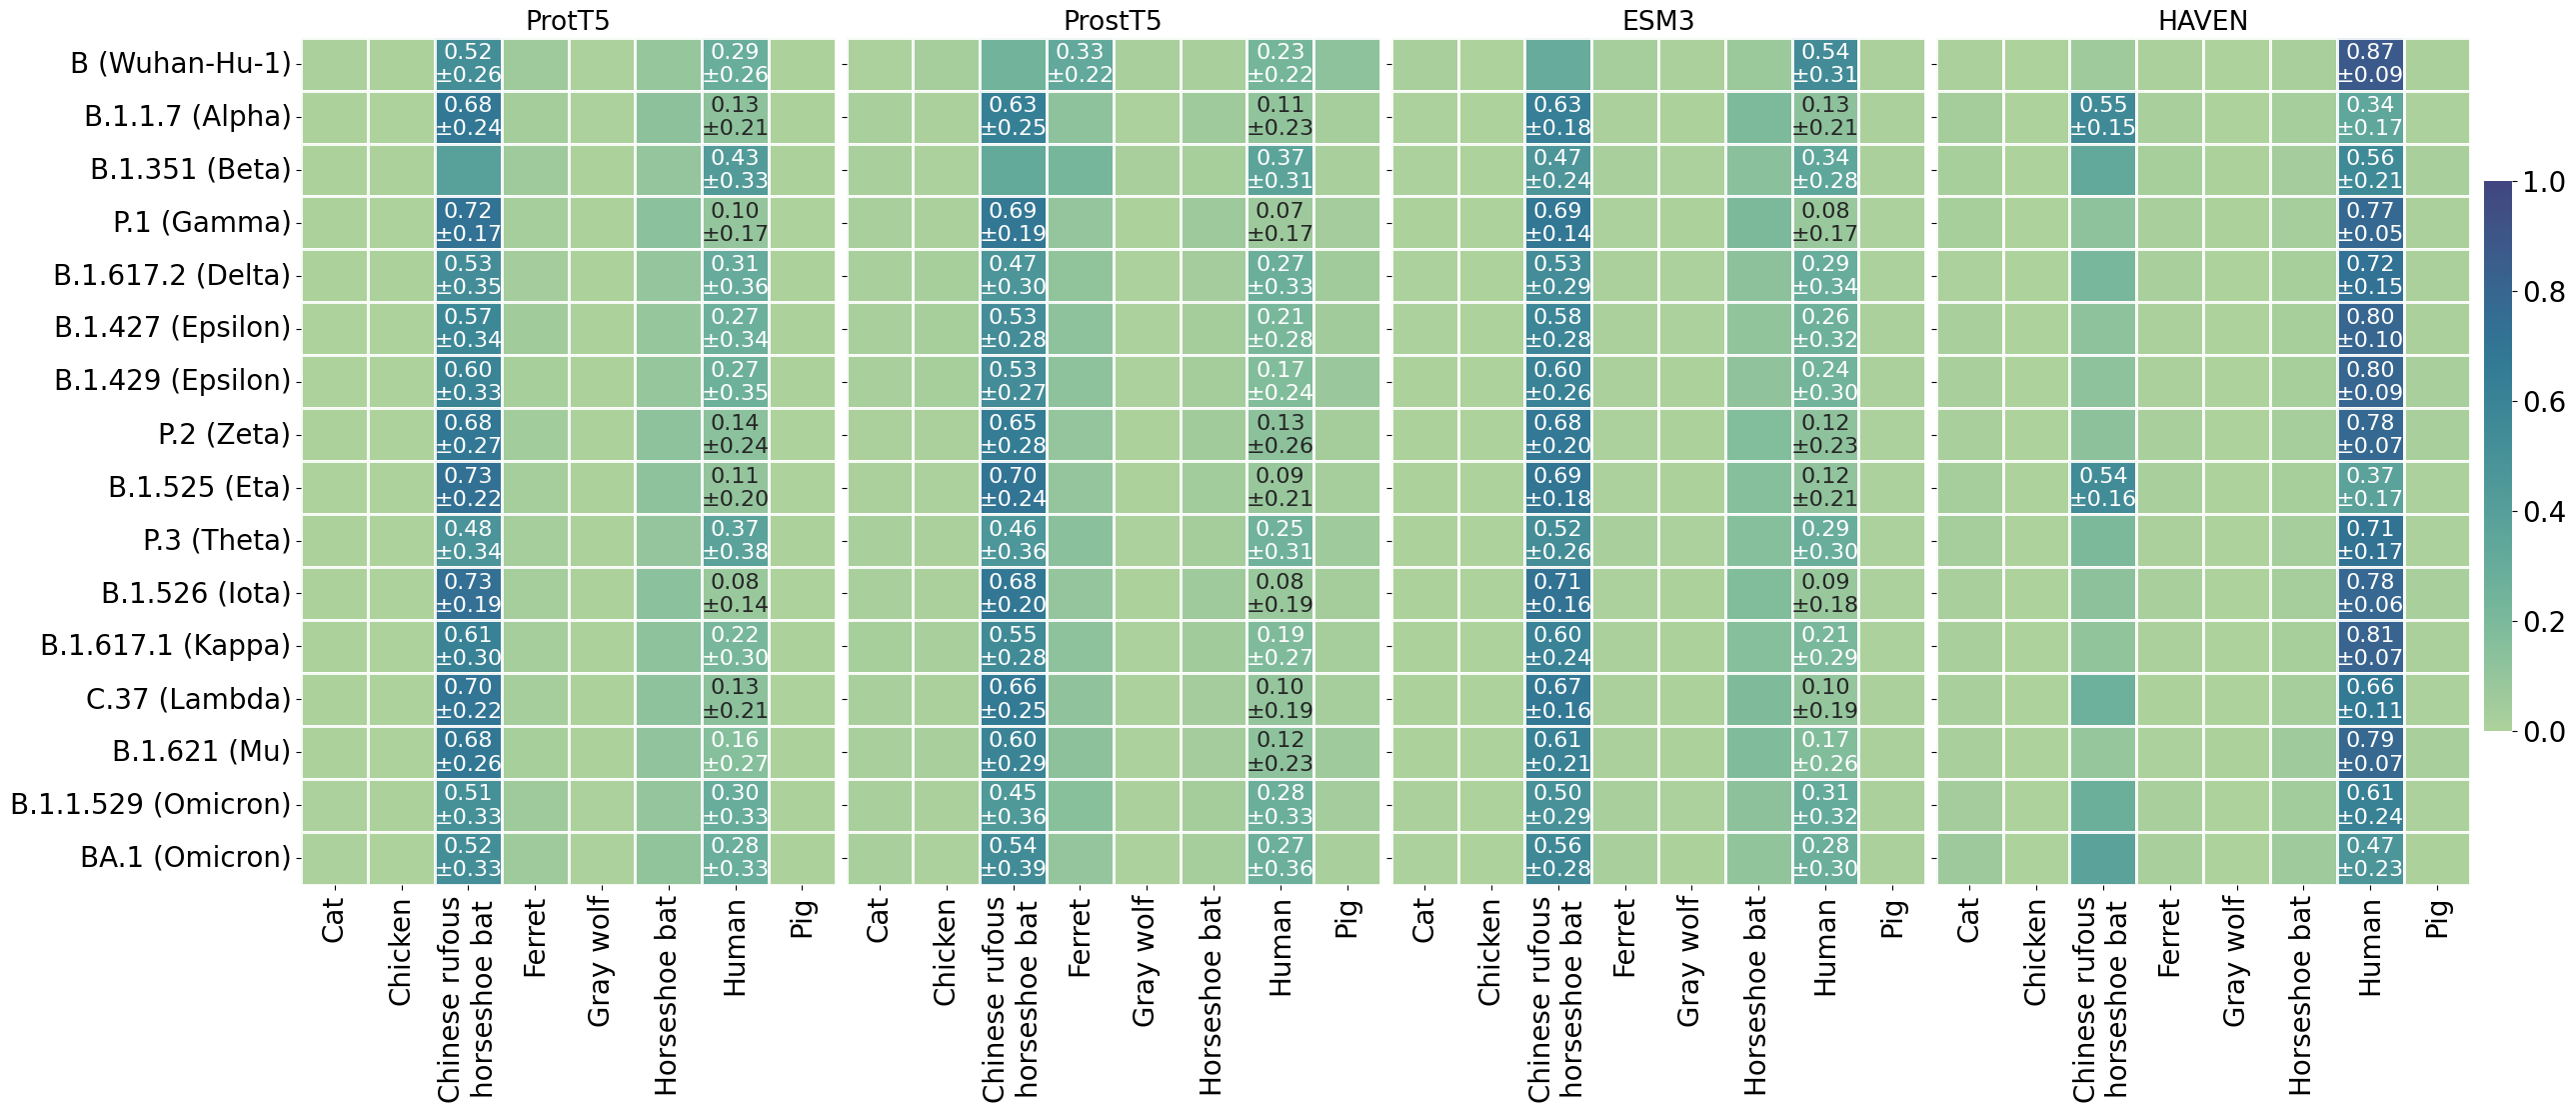

In [19]:
plt.rcParams['xtick.labelsize'] = 20
plt.rcParams['ytick.labelsize'] = 20
plt.rcParams.update({'font.size': 16})
fig, axs = plt.subplots(1, 4, figsize=(28, 11), sharex=False, sharey=True)

cbar_ax = fig.add_axes([.905, .25, .01, .5])
for i, model in enumerate(models):
    model_df = df[df["model"] == model][["Cat", "Chicken", "Chinese rufous horseshoe bat", "Ferret", "Gray wolf", "Horseshoe bat", "Human", "Pig", "pango_who_annotation"]].set_index("pango_who_annotation")
    print(f"model = {model_df.shape}")
    heatmap_df = model_df.groupby("pango_who_annotation").agg("mean").reindex(variant_order)
    model_df.rename(columns={"Chinese rufous horseshoe bat": "Chinese rufous\nhorseshoe bat"}, inplace=True)
    heatmap_df.rename(columns={"Chinese rufous horseshoe bat": "Chinese rufous\nhorseshoe bat"}, inplace=True)
    sns.heatmap(heatmap_df, ax=axs[i], linewidth=2,
                annot=get_annotation_df(heatmap_df, model_df), fmt="",
                vmin=0, vmax=1,
                cbar=i == 0, 
                cbar_ax=None if i != 0 else cbar_ax,
                cmap="crest", alpha=.9)
    axs[i].set_title(model)
    axs[i].set(xlabel="", ylabel="")
plt.subplots_adjust(wspace=0.02)
plt.savefig(os.path.join(os.getcwd(), "..", "..", "..", "..", f"output/visualization/haven/sarscov2_variants_uniref90.pdf"), bbox_inches="tight")
plt.show()

model = (1526, 8)
model = (1526, 8)
model = (1526, 8)
model = (1526, 8)


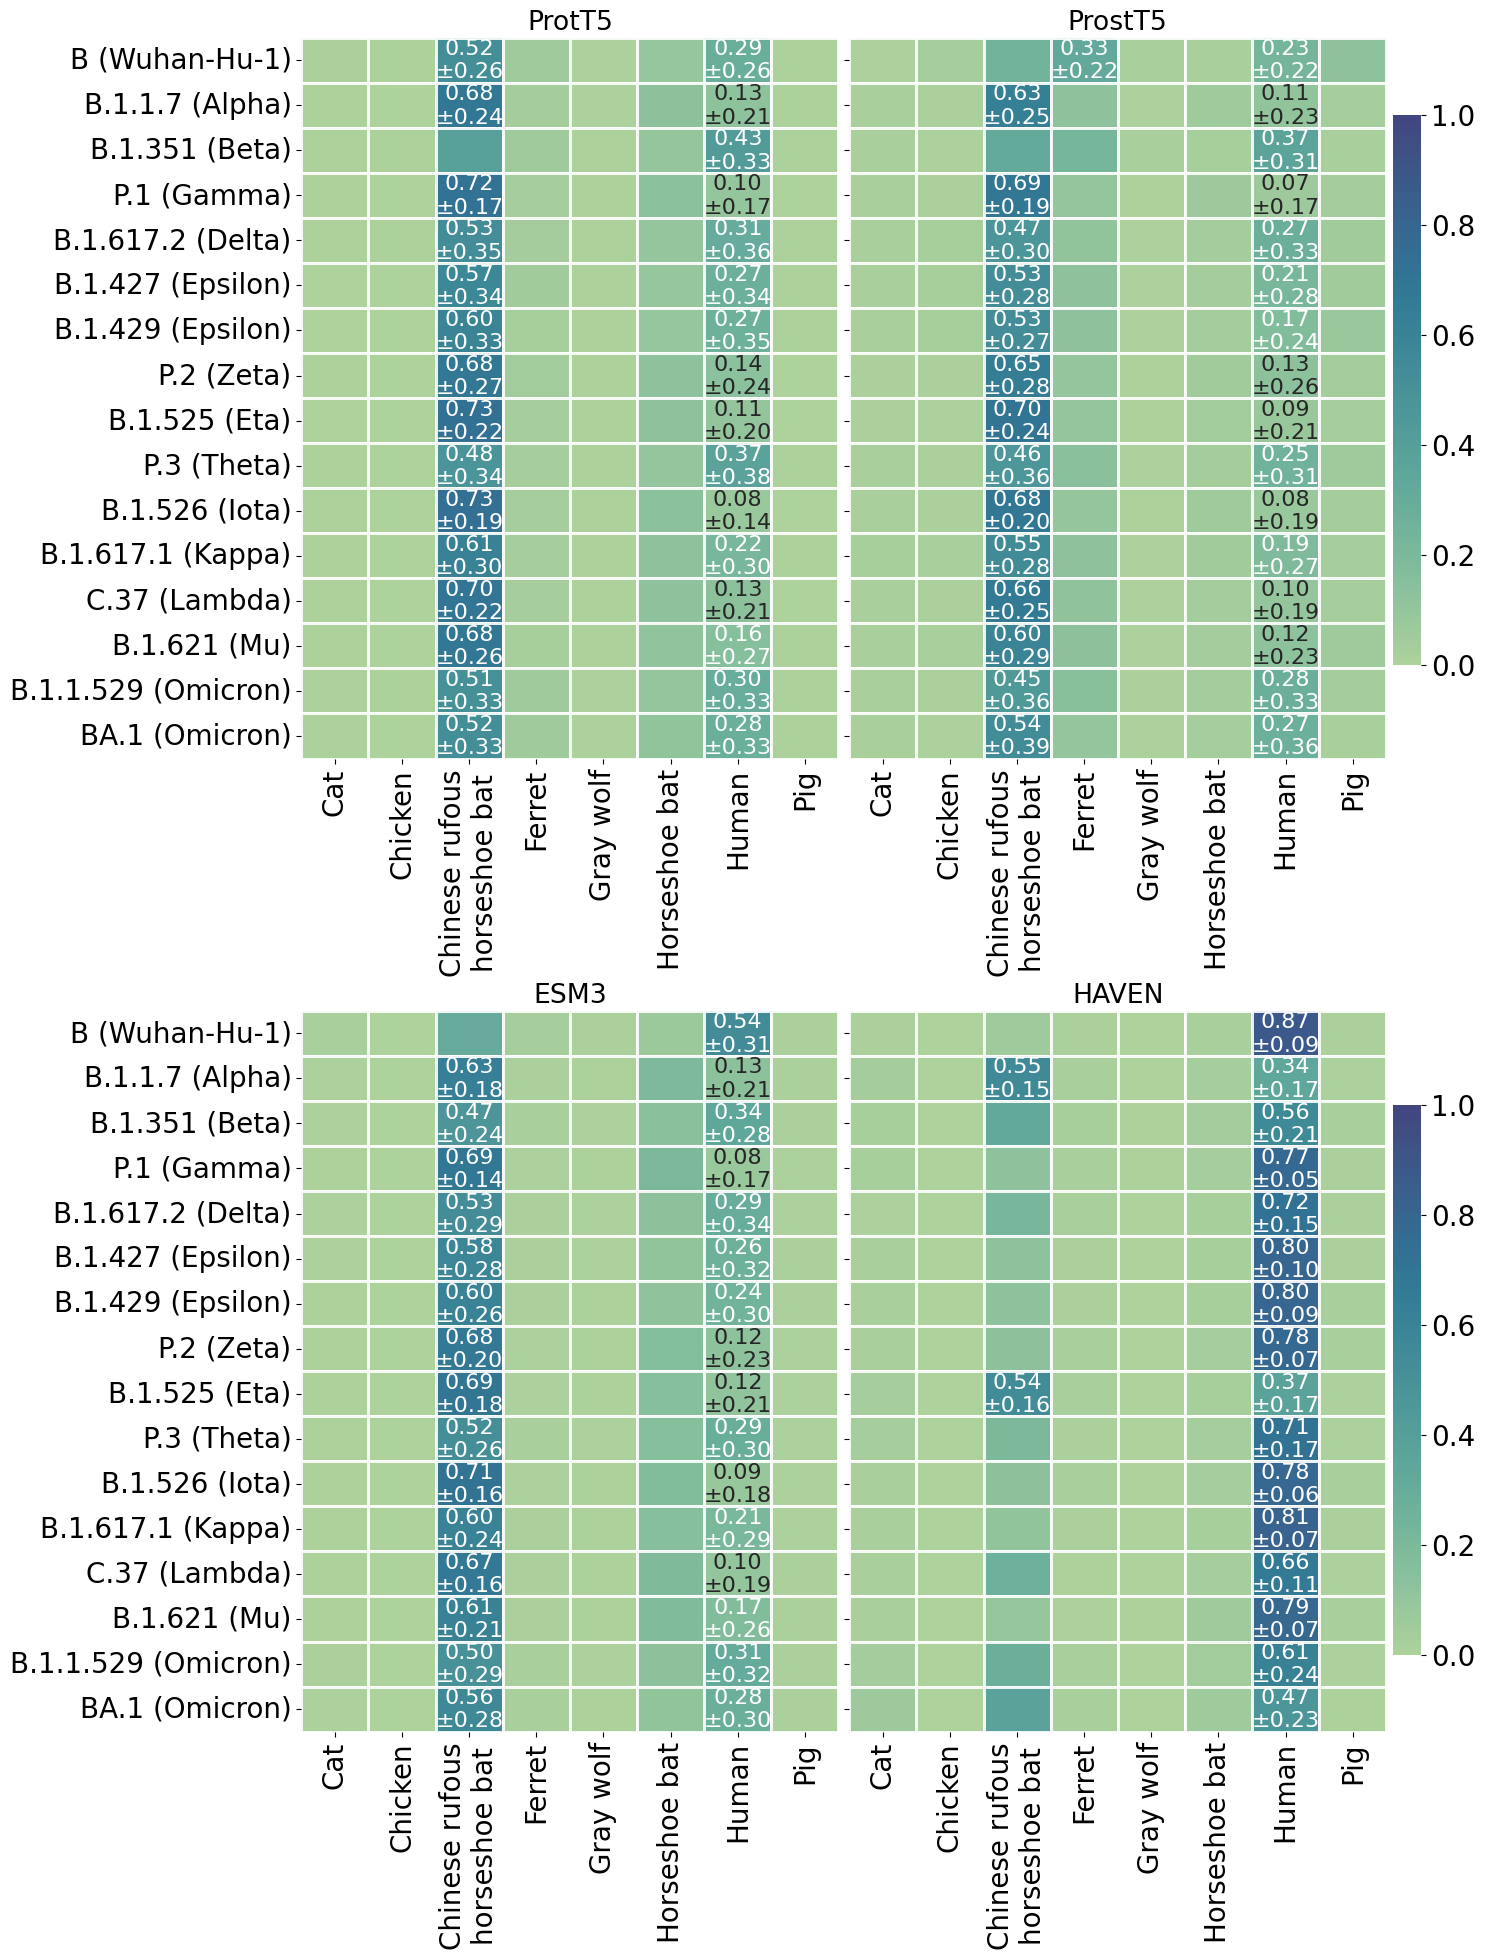

In [25]:
plt.rcParams['xtick.labelsize'] = 20
plt.rcParams['ytick.labelsize'] = 20
plt.rcParams.update({'font.size': 16})
fig, axs = plt.subplots(2, 2, figsize=(14, 22), sharex=False, sharey=True)
axs = axs.flatten()
cbar_ax_0 = fig.add_axes([.905, .145, .02, .25])
cbar_ax_1 = fig.add_axes([.905, .595, .02, .25])
def get_cbar_ax(i):
    if i == 0:
        return cbar_ax_0
    elif i == 2:
        return cbar_ax_1
    else:
        return None
        
for i, model in enumerate(models):
    model_df = df[df["model"] == model][["Cat", "Chicken", "Chinese rufous horseshoe bat", "Ferret", "Gray wolf", "Horseshoe bat", "Human", "Pig", "pango_who_annotation"]].set_index("pango_who_annotation")
    print(f"model = {model_df.shape}")
    heatmap_df = model_df.groupby("pango_who_annotation").agg("mean").reindex(variant_order)
    model_df.rename(columns={"Chinese rufous horseshoe bat": "Chinese rufous\nhorseshoe bat"}, inplace=True)
    heatmap_df.rename(columns={"Chinese rufous horseshoe bat": "Chinese rufous\nhorseshoe bat"}, inplace=True)
    sns.heatmap(heatmap_df, ax=axs[i], linewidth=2,
                annot=get_annotation_df(heatmap_df, model_df), fmt="",
                vmin=0, vmax=1,
                cbar=i == 0 or i == 2, 
                cbar_ax=get_cbar_ax(i),
                cmap="crest", alpha=.9)
    axs[i].set_title(model)
    axs[i].set(xlabel="", ylabel="")
plt.subplots_adjust(wspace=0.02)
plt.subplots_adjust(hspace=0.35)
plt.savefig(os.path.join(os.getcwd(), "..", "..", "..", "..", f"output/visualization/haven/sarscov2_variants_uniref90_2by2.pdf"), bbox_inches="tight")
plt.show()

In [21]:
df

,accession_id,Cat,Chicken,Chinese rufous horseshoe bat,Ferret,Gray wolf,Horseshoe bat,Human,Pig,y_true,pangolin_lineage,geo_location,seq_length,model,Human_pred_diff,who_variant,designation,first_designation_date,location,pango_who_annotation
0,UDW43218.1,0.006330,0.010504,0.006680,0.032874,0.005100,0.019163,0.909526,0.009823,Human,C.37,USA: Texas,1266.0,ProtT5,0.877108,Lambda,VOI,6/14/2021,Peru,C.37 (Lambda)
1,UEY25537.1,0.005365,0.001463,0.795068,0.017764,0.005350,0.131605,0.040536,0.002848,Human,C.37,USA: Florida,1266.0,ProtT5,0.008118,Lambda,VOI,6/14/2021,Peru,C.37 (Lambda)
2,WZA34221.1,0.005821,0.001438,0.812252,0.021100,0.005605,0.097729,0.053151,0.002904,Human,C.37,USA,1266.0,ProtT5,0.020733,Lambda,VOI,6/14/2021,Peru,C.37 (Lambda)
3,QUX56427.1,0.005365,0.001463,0.795068,0.017764,0.005350,0.131605,0.040536,0.002848,Human,C.37,USA: Florida,1266.0,ProtT5,0.008118,Lambda,VOI,6/14/2021,Peru,C.37 (Lambda)
4,QXI95098.1,0.005365,0.001463,0.795068,0.017764,0.005350,0.131605,0.040536,0.002848,Human,C.37,"USA: Birmingham, AL",1266.0,ProtT5,0.008118,Lambda,VOI,6/14/2021,Peru,C.37 (Lambda)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6099,QWO25630.1,0.010672,0.000456,0.371819,0.024800,0.012889,0.084983,0.480310,0.014071,Human,P.3,NaN,NaN,ESM3,NaN,Theta,VOI,3/24/2021,Philippines,P.3 (Theta)
6100,UHM88537.1,0.004705,0.000537,0.664873,0.017255,0.011104,0.087092,0.201772,0.012663,Human,P.3,NaN,NaN,ESM3,NaN,Theta,VOI,3/24/2021,Philippines,P.3 (Theta)
6101,QWO25594.1,0.010177,0.000237,0.182567,0.023745,0.014315,0.074424,0.683256,0.011278,Human,P.3,NaN,NaN,ESM3,NaN,Theta,VOI,3/24/2021,Philippines,P.3 (Theta)
6102,UHM17599.1,0.002385,0.001172,0.709533,0.008858,0.003624,0.227563,0.038156,0.008710,Human,P.3,NaN,NaN,ESM3,NaN,Theta,VOI,3/24/2021,Philippines,P.3 (Theta)


In [22]:
sub_df = df[["pango_who_annotation", "model", "Chinese rufous horseshoe bat", "Human"]]
sub_df = sub_df.set_index(["pango_who_annotation", "model"]).stack().reset_index().rename(columns={"level_2": "class", 0: "probability"})
sub_df

,pango_who_annotation,model,class,probability
0,C.37 (Lambda),ProtT5,Chinese rufous horseshoe bat,0.006680
1,C.37 (Lambda),ProtT5,Human,0.909526
2,C.37 (Lambda),ProtT5,Chinese rufous horseshoe bat,0.795068
3,C.37 (Lambda),ProtT5,Human,0.040536
4,C.37 (Lambda),ProtT5,Chinese rufous horseshoe bat,0.812252
...,...,...,...,...
12203,P.3 (Theta),ESM3,Human,0.683256
12204,P.3 (Theta),ESM3,Chinese rufous horseshoe bat,0.709533
12205,P.3 (Theta),ESM3,Human,0.038156
12206,P.3 (Theta),ESM3,Chinese rufous horseshoe bat,0.752988


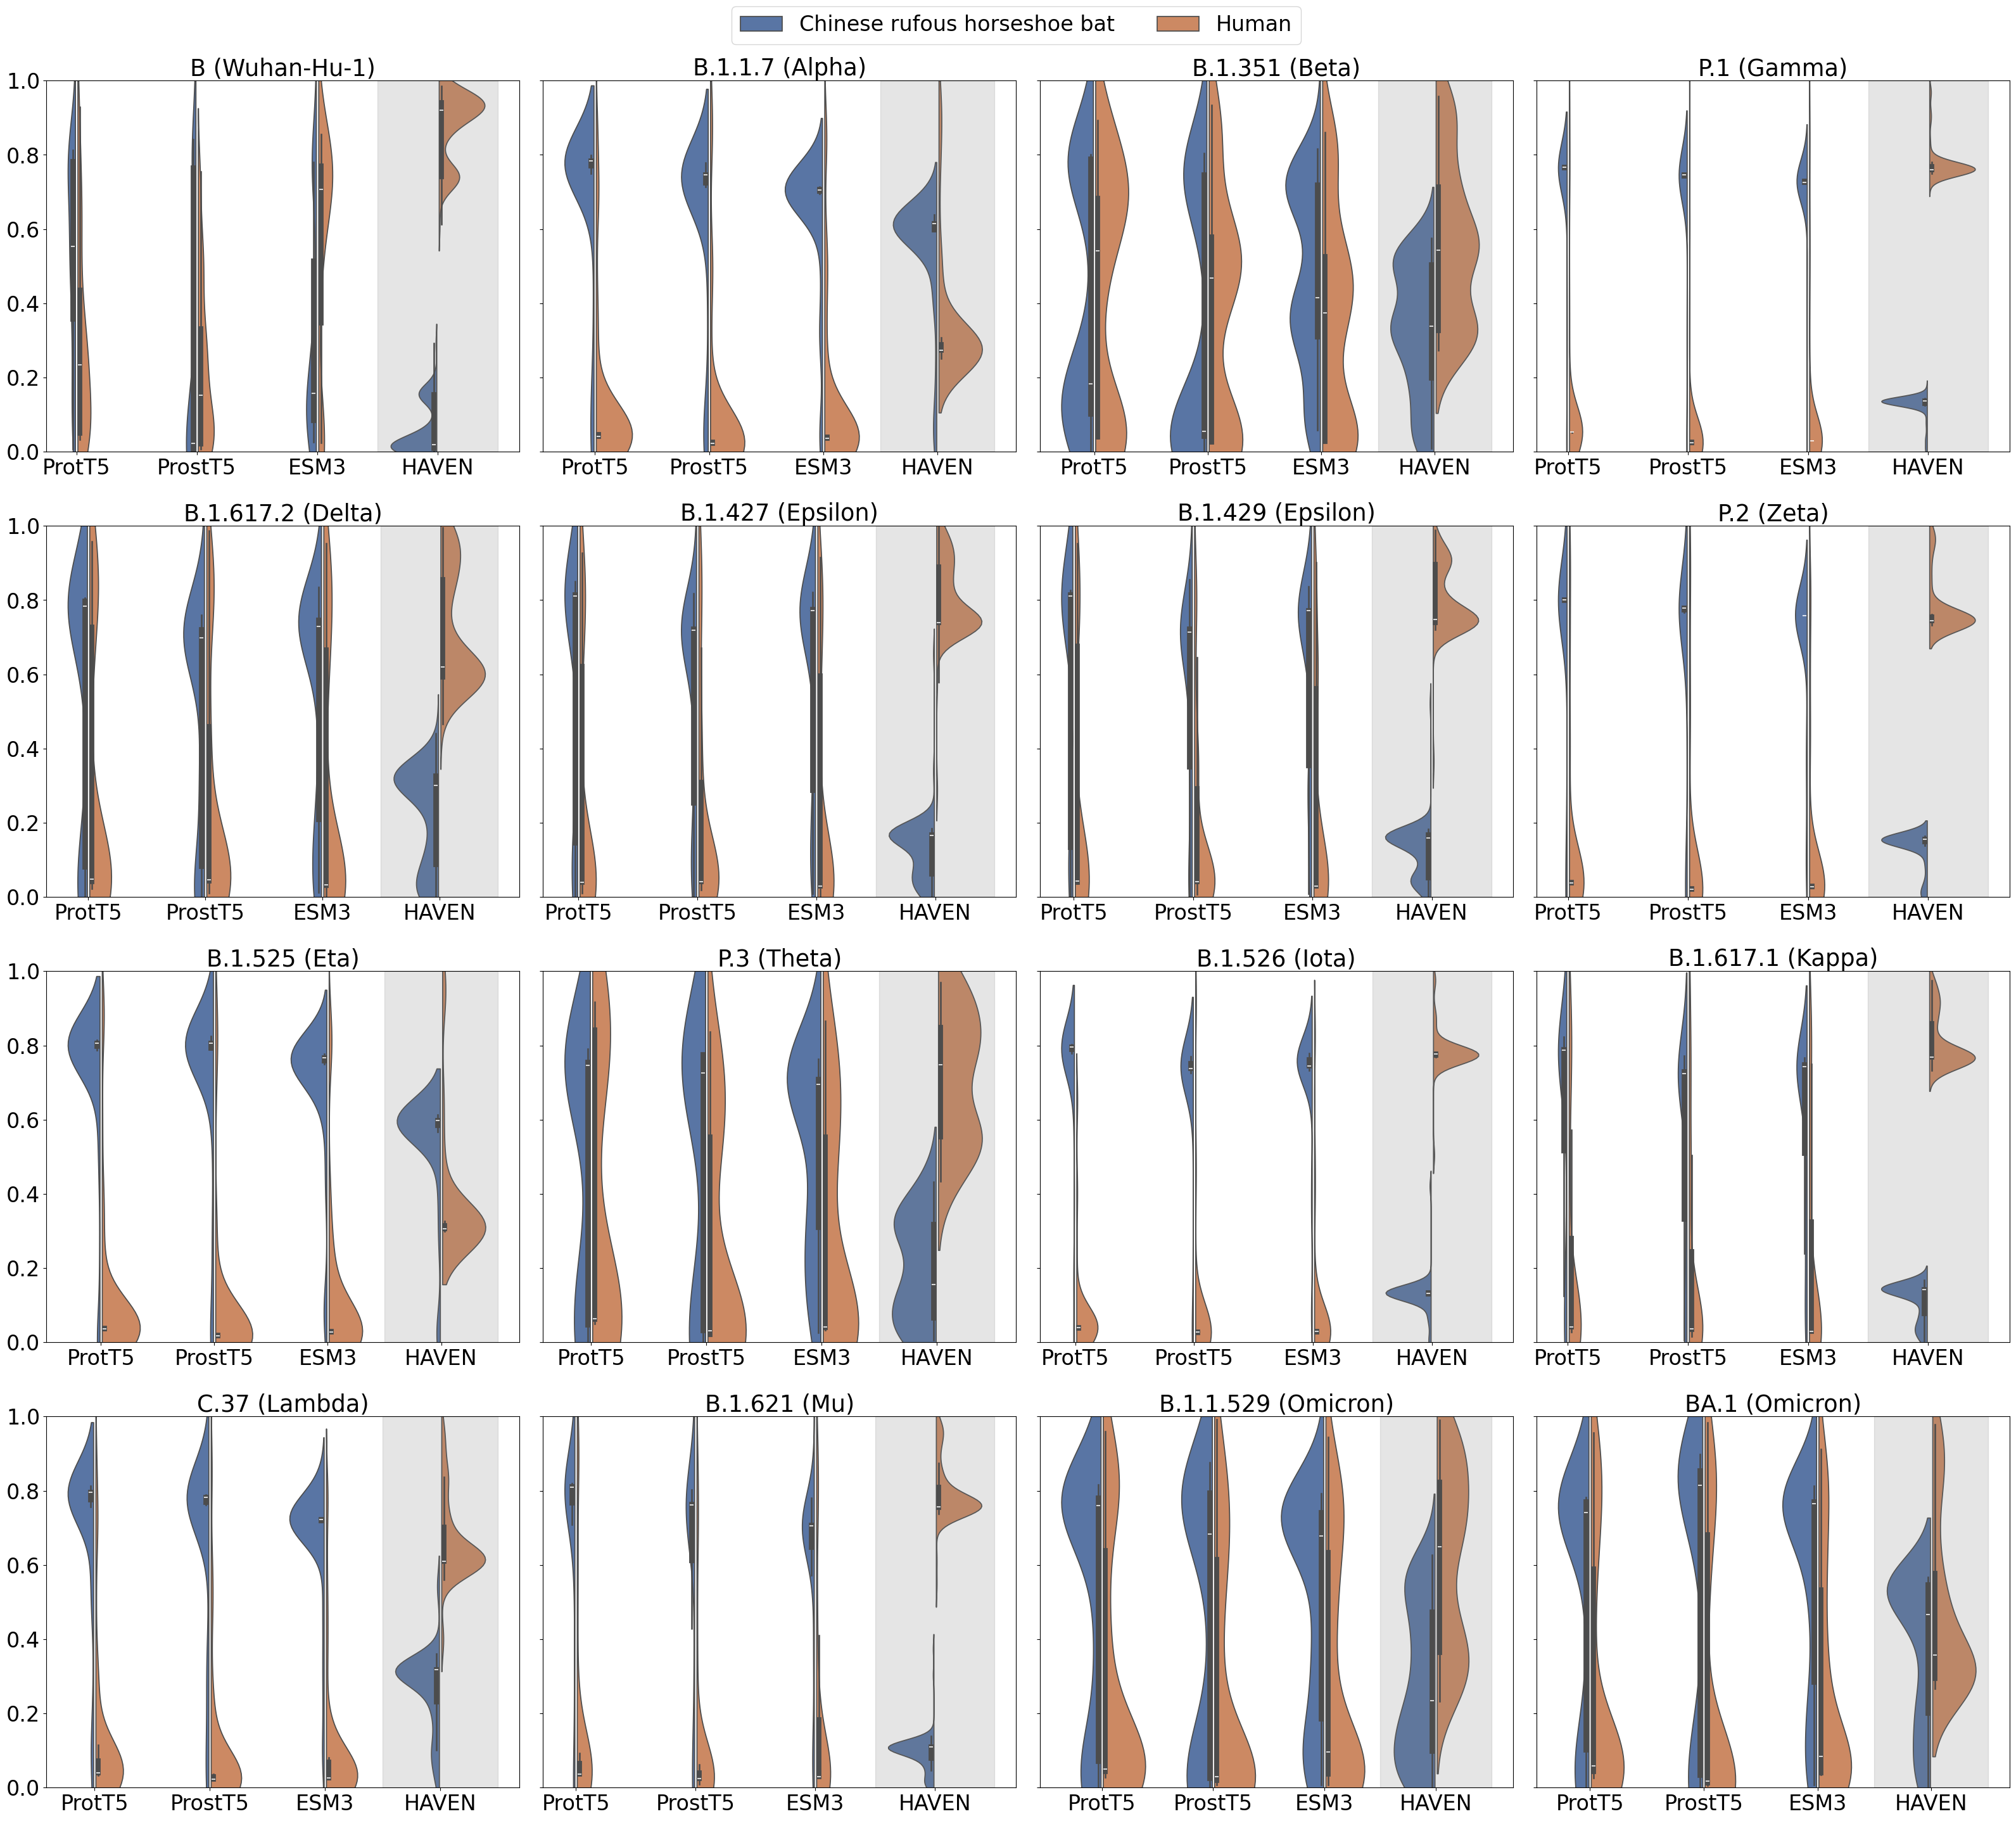

In [23]:
plt.rcParams['xtick.labelsize'] = 24
plt.rcParams['ytick.labelsize'] = 24
plt.rcParams.update({'font.size': 22})
fig, axs = plt.subplots(4, 4, figsize=(40, 35), sharex=False, sharey=True)

i = 0
legend_ax = None
virprobert_index = len(models) - 1
for ax_row in axs:
    for ax in ax_row:
        if i == 1:
            legend_ax = ax
        variant = variant_order[i]
        plot_df = sub_df[sub_df["pango_who_annotation"] == variant][["model", "class", "probability"]]
        sns.violinplot(plot_df, x="model", y="probability", hue="class", ax=ax, 
                       split=True, gap=.05, fill=True, palette="deep", order=models,
                      legend=False if i != 1 else True)
        ax.set_title(variant)
        ax.set(xlabel="", ylabel="")
        i += 1
        ax.axvspan(virprobert_index - .5, virprobert_index + .5, color="gray", alpha=0.2)
        ax.set_ylim(0, 1)

for ax in axs.flat:
    ## check if something was plotted 
    if not bool(ax.has_data()):
        fig.delaxes(ax) ## delete if nothing is plotted in the axes obj
        
sns.move_legend(
    legend_ax, "lower center",
    bbox_to_anchor=(1, 1.07), ncol=2, title=None, frameon=True, fontsize=24
)
plt.subplots_adjust(wspace=0.05)
plt.savefig(os.path.join(os.getcwd(), "..", "..", "..", "..", f"output/visualization/temp_new/sarscov2_variants_uniref90_crhb_human_violinplot.pdf"), bbox_inches="tight")
plt.show()